## Multicellular Factor Analysis across datasets with MOFA+ grouping strategy

---
**NOTE**  
This is an advanced user notebook. Familiarity with MOFA-based multicellular factor analysis is assumed.

---

In many applications, data are collected across multiple studies, cohorts, or experimental batches. These datasets often share underlying biological structure, while also containing dataset-specific effects arising from technical or contextual differences.

While one could use projections to compare distinct batches, a better strategy is to model this explicitly. [**MOFA+**](https://link.springer.com/article/10.1186/s13059-020-02015-1) extends factor analysis to jointly analyze multiple groups of samples, enabling the decomposition of variability into:

- **Shared factors**: capturing variation common across datasets  
- **Group-specific factors**: capturing variation unique to each dataset  

This grouping strategy allows the model to distinguish reproducible biological signals from dataset-specific effects, without requiring prior data integration or batch correction.

---

### Why use joint modeling?

Joint modeling is useful when:
- multiple datasets profile similar biological systems  
- there is interest in identifying **reproducible multicellular programs**  
- datasets contain **batch or study-specific effects** that should be separated from shared biology  

In contrast to simple concatenation or integration, MOFA+ provides a structured way to **partition variability across datasets**, improving interpretability.

---

### Application to Crohn’s disease data

To illustrate this, we consider two batches from a single inflammatory bowel disease (IBD) study. Although these batches profile comparable biological samples, they may differ due to technical or experimental factors.

Using MOFA+ grouping, we:
- treat each batch as a separate group  
- jointly model their variation within a shared latent space  

This allows us to:
- identify **shared multicellular programs** consistent across batches  
- isolate **batch-specific sources of variation**  

As a result, we can assess the robustness of inferred programs and distinguish biological signals from technical variability.

---

In [1]:
import mina
import scanpy as sc
import scanpy.external as sce
import numpy as np
import decoupler as dc
import math
import mofaflex as mf
import mudata as md
import pandas as pd
import matplotlib.pyplot as plt

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



To illustrate the use of guided models, we apply MINA to a Crohn’s disease dataset. Crohn’s disease is a chronic inflammatory disorder of the gastrointestinal tract, characterized by patchy, transmural inflammation.

Here we re-analyse epithelial cells from the [scIBD atlas](https://www.nature.com/articles/s41586-025-09907-x), focusing on ileal biopsies from [Kong et al., 2023](https://www.sciencedirect.com/science/article/pii/S1074761323000122?via%3Dihub). Here we treat the two library preparation protocols as two distinct datasets to integrate.

### 10x 3' v3

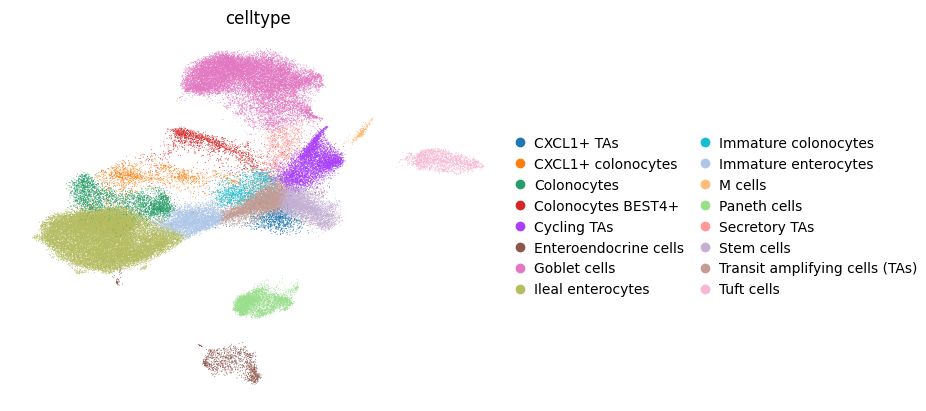

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:795: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['H101694_E', 'H101694_L', 'H102141_E', 'H102141_L', 'H110216_E']

    Inferred to be: categorical



Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


/Users/flores/Dropbox/EBI/Research/MINA/src/mina/up/filt.py:126: RuntimeWarning: invalid value encountered in divide
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide


In [3]:
# Doing pre-processing of dataset number 1
adata = sc.read_h5ad("./data/scIBD/KongEpi_adata_ref.h5ad")
sc.pl.umap(adata, color=['celltype'], frameon=False, ncols=2)
adata = adata[adata.obs["organ"] == "Ileum", :].copy()
# Process adata_raw
metadata = mina.up.extract_metadata_from_obs(obs=adata.obs, groupby="biosample_id", sort=False)
metadata["study_group"] = "KongChemA"
pdata = dc.pp.pseudobulk(adata, sample_col="biosample_id", groups_col="celltype")
# Manipulations on pdata
pdata.obs = pdata.obs.set_index("biosample_id", drop=False)
pdata.obs.index.name = None

# Make list of adatas per pseudobulk cell type
anndata_dict = mina.up.split_anndata_by_celltype(pdata=pdata, grouping="celltype")

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts

# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples = math.trunc(n_samples * 0.4)

# Processing
mina.up.filt.filter_anndata_by_ncells(anndata_dict, min_cells=20)
mina.up.filt.filter_genes_byexpr(anndata_dict, min_count=20, min_prop=0.4)
mina.up.filt.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mina.up.filt.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.90)
mina.up.filt.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.utils.save_raw_counts(anndata_dict, layer_name="raw_counts")
mina.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
#mina.up.filter_hvgs(anndata_dict, groupby = None, ngroups_cut = None)
mina.up.filter_smpls_by_nview(anndata_dict, min_views = 5)

### 10x 3' v2

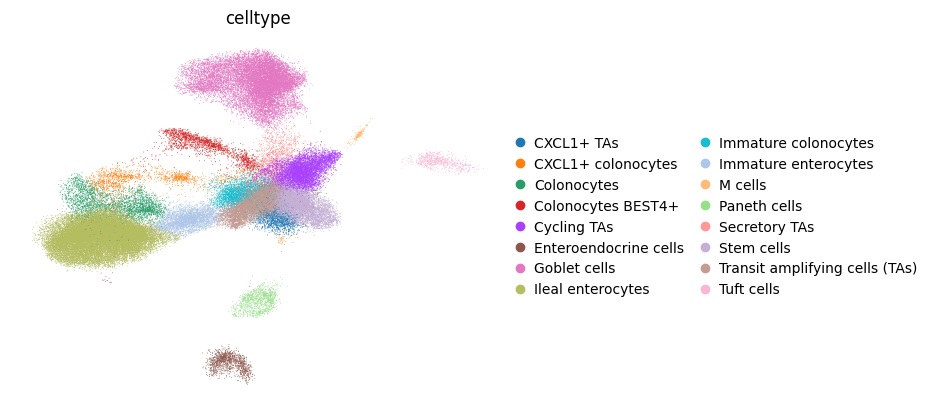

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:795: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['H106265_N', 'H139073_N', 'H158108_N1', 'H158108_N2', 'H158108_N3']

    Inferred to be: categorical



Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


In [4]:
# Doing pre-processing of dataset number 2
adata_proj = sc.read_h5ad("./data/scIBD/KongEpi_adata_proj.h5ad")
sc.pl.umap(adata_proj, color=['celltype'], frameon=False, ncols=2)
# Process adata_raw
metadata_proj = mina.up.extract_metadata_from_obs(obs=adata_proj.obs, groupby="biosample_id", sort=False)
metadata_proj["study_group"] = "KongChemB"
pdata_proj = dc.pp.pseudobulk(adata_proj, sample_col="biosample_id", groups_col="celltype")
# Manipulations on pdata
pdata_proj.obs = pdata_proj.obs.set_index("biosample_id", drop=False)
pdata_proj.obs.index.name = None
anndata_dict_proj = mina.up.split_anndata_by_celltype(pdata=pdata_proj, grouping="celltype")

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict_proj.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts

mina.up.filter_anndata_by_ncells(anndata_dict_proj, min_cells=10)
# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata_proj.index)
min_samples = math.trunc(n_samples * 0.4)
mina.up.filter_views_by_samples(anndata_dict_proj, min_rows=min_samples)
mina.up.filter_genes_byexpr(anndata_dict_proj, min_count=5, min_prop=0.4)
mina.up.filter_views_by_genes(anndata_dict_proj, min_genes_per_view=20)
mina.up.filter_samples_by_coverage(anndata_dict_proj, threshold=0, min_prop=0.90)
mina.up.filter_views_by_samples(anndata_dict_proj, min_rows=min_samples)
mina.up.utils.save_raw_counts(anndata_dict_proj, layer_name="raw_counts")
mina.up.norm_log(anndata_dict_proj, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
#mina.up.filter_hvgs(anndata_dict, groupby = None, ngroups_cut = None)
#mina.up.append_view_to_var(anndata_dict_proj)

## Merging multiple studies across views

This function merges multiple studies into a unified set of AnnData objects, where each study is represented as a dictionary of views (e.g. cell types, modalities, or compartments).

In MINA we provide a wrapper that allows to align distinct datasets in a single multi-view structure. We assume that datasets are somehow homogenized in annotations, since it will only keep similar things.

In other words,ensure both your views and metadata contain similar information.

The merging can look complicated but merge operates at two levels:
1. **View selection** (which views to retain across studies)  
2. **Feature selection** (which genes to retain within each merged view)  

---

### 1. View selection (view_mode)

Determines which views are retained before merging:

- **Union**  
  Keep all views present in at least one study  

- **Intersection**  
  Keep only views shared across all studies  

- **Minimum number (`min_n`)**  
  Keep views present in at least a specified number of studies (`min_view_studies`)  

This controls the **coverage vs comparability trade-off** at the level of views.

---

### 2. Feature selection (var_mode)

After selecting a view, the corresponding AnnData objects are concatenated across studies.  
`var_mode` determines which genes/features are retained:

- **Outer**  
  Keep all genes present in any study (union)  

- **Inner**  
  Keep only genes shared across all studies (intersection)  

- **Minimum number (`min_n`)**  
  Keep genes present in at least a specified number of studies (`min_var_studies`)  

This controls the **coverage vs consistency trade-off** at the feature level.

---

### 3. Merging procedure

For each retained view:
- collect AnnData objects from studies containing that view  
- annotate cells with their study of origin  
- concatenate cells across studies  
- retain only shared metadata columns  
- subset genes according to the selected feature mode  

The result is one AnnData object per view with:
- **rows**: cells from all contributing studies  
- **columns**: selected genes  

---

### 4. Practical configurations

- **Conservative merge**  
  Keep only shared views and shared genes across all studies  
  → maximizes comparability, reduces coverage  

- **Permissive merge**  
  Keep all views and all genes across studies  
  → maximizes coverage, may introduce sparsity and heterogeneity  

- **Balanced approach**  
  Keep views and genes observed in at least a minimum number of studies  
  → balances robustness and coverage, often suitable for multi-study data  

---

In [5]:
# Merging datasets
anndata_merged = mina.up.merge_adata_views(
    studies = [anndata_dict, anndata_dict_proj],
    study_names = ["ChemA", "ChemB"],
    view_mode = "intersection",
    min_view_studies = 2,
    var_mode = "inner",
    min_var_studies = 2
)

mina.up.utils.append_view_to_var(anndata_merged)

In addition, all the metadata needs to be combined to use downstream analyses 

In [6]:
metadata_merged = pd.concat([metadata, metadata_proj], join="inner", axis=0)

Finally, and **VERY IMPORTANTLY** add your group information in the .obs of the mudata we will use for modeling  

In [7]:
model_data = md.MuData(anndata_merged)
model_data.obs["study_group"] = model_data.obs.index.map(metadata_merged["study_group"])

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


### Fitting the model with MOFA-FLEX

Here, we use MOFA-FLEX to incorporate a group-level covariate (`study_group`) and build a group model. 

As a result, the model is configured with:
- **5 unguided factors** capturing the variation of the two studies and all cell-types simultaneously

---

Guided modeling requires specifying one parameter in `DataOptions`, which is the "study_group"

2026-03-27 15:10:01 | [WARNING] Device cuda is not available. Using default device: cpu


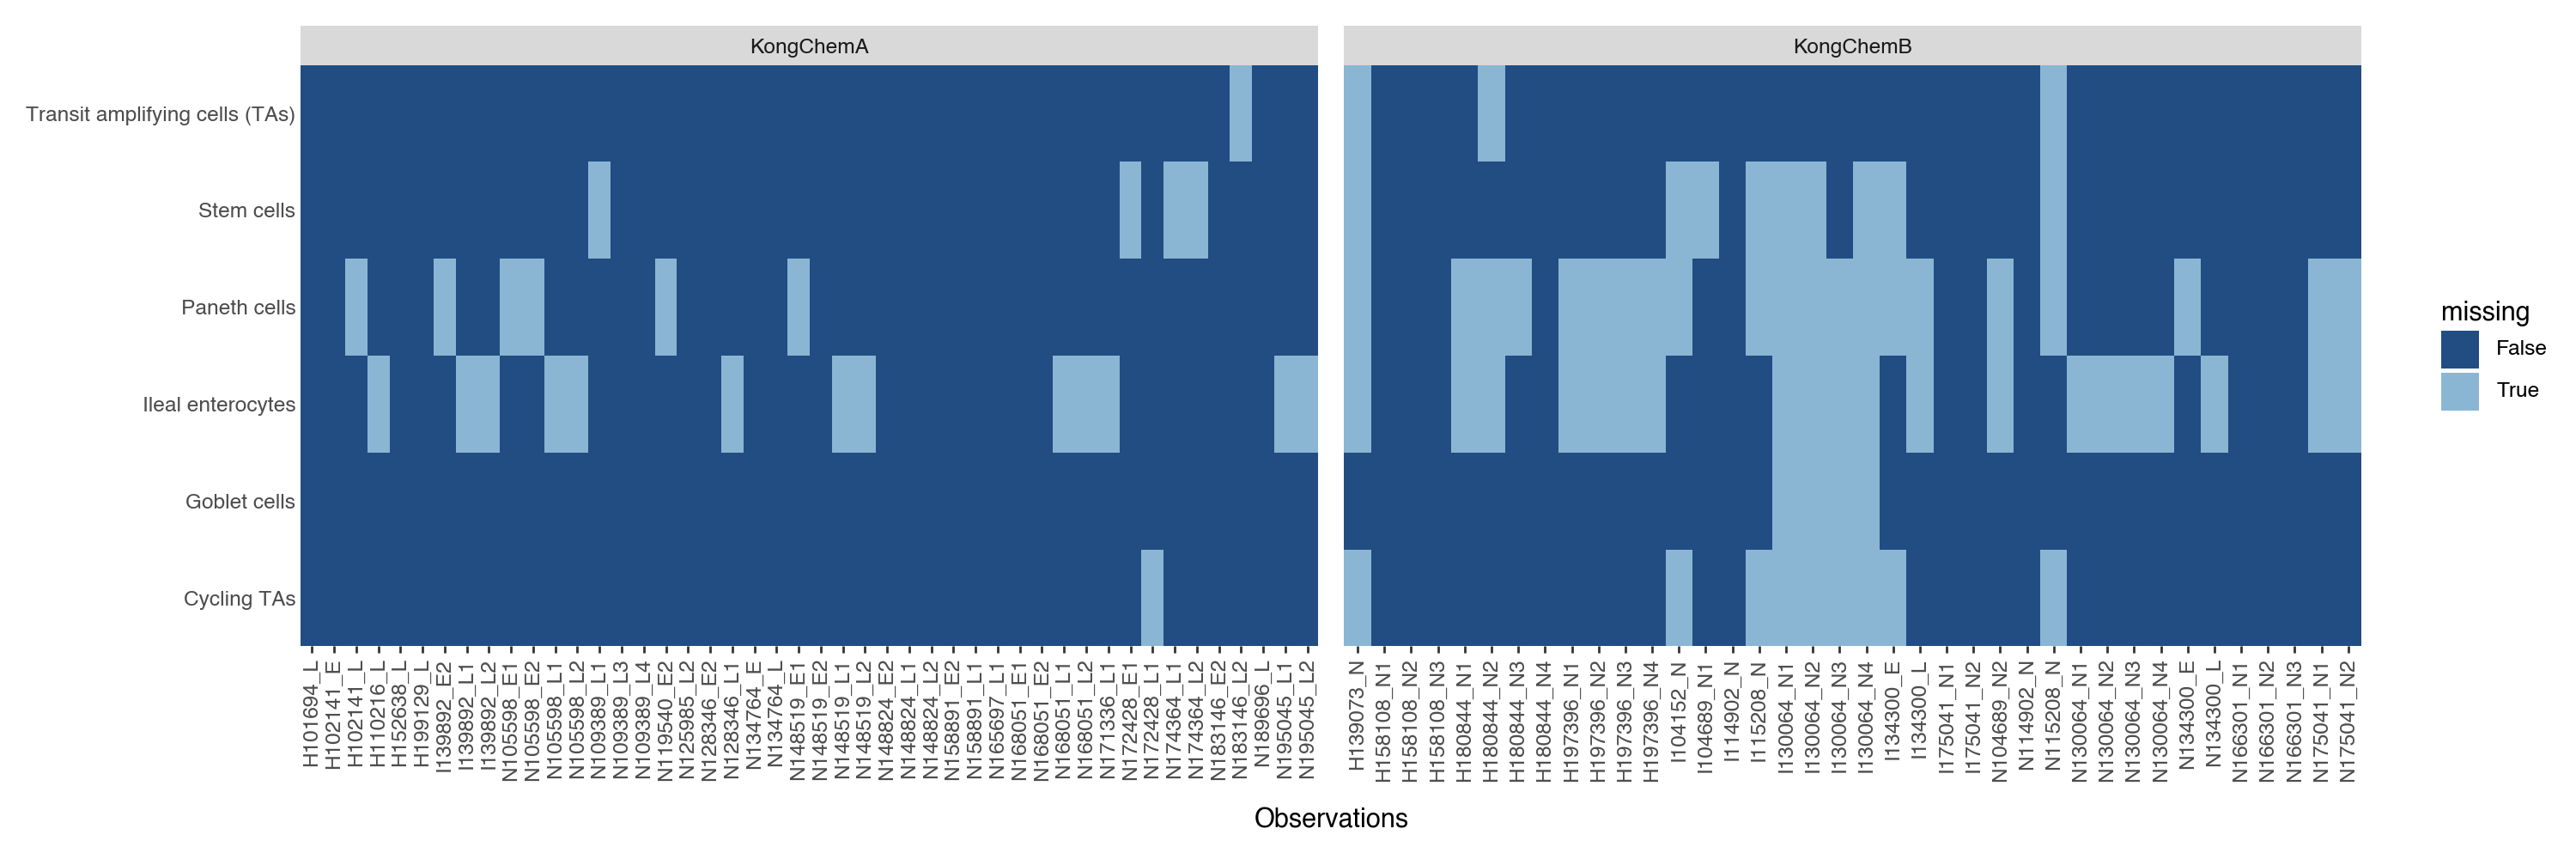

2026-03-27 15:10:01 | [WARNING] Could not import dask. Data arrays may be copied, resulting in high memory usage.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
2026-03-27 15:10:01 | [INFO] Initializing factors using `random` method...
 15%|█▌

In [8]:
model_group = mf.MOFAFLEX(
    model_data,
    mf.ModelOptions(n_factors=5, weight_prior="SnS", likelihoods="Normal"),
    mf.DataOptions(group_by="study_group"),
    mf.TrainingOptions(seed=42, save_path=False, lr=0.01, early_stopper_patience=500)
)

## Outputs of joint multicellular factor analysis (MOFA+)

Joint modeling with MOFA+ produces the same core outputs as standard factor models, but extends them to explicitly capture **shared and group-specific variation across datasets**.

---

### 1. Factor scores - shared between groups

- Matrix of size *(samples × factors)*, defined for each group (e.g. study or batch)  
- Represent the position of samples in the shared latent space  

Interpretation:
- **Shared factors**: comparable across groups → enable direct comparison of samples from different datasets  
- **Group-specific factors**: defined within a single group → capture within-dataset variation  

---

### 2. Explained variance (per factor and per group)

- Quantifies how much variance each factor explains  
- Computed:
  - per group (dataset-specific contribution)  
  - optionally per view (cell type / modality)  

Interpretation:
- **Shared factors** → explain variance across multiple groups  
- **Group-specific factors** → explain variance restricted to one group  

This allows direct assessment of whether a factor reflects **reproducible biology or dataset-specific effects**.

---

### 3. Factor loadings (per view) - shared between groups

- Matrix *(features × factors)* for each view (e.g. cell type)  
- Define how features (genes) contribute to each factor  

Interpretation:
- Shared factors often show **consistent loadings across groups**  
- Group-specific factors may reveal **dataset-specific gene programs**  

Loadings remain the main tool for biological interpretation of factors.

---

In MINA we have taken these differences into account when building the anndata use for downstream analyses

In [22]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_merged, # Add the merged anndata here
    metadata=metadata_merged, # Add the merged metadata here
    model=model_group,
)

The difference in this model is that in `.var` we store the explained variance per view and group separately

In [23]:
amodel.var

,Stem cells:KongChemA,Paneth cells:KongChemA,Cycling TAs:KongChemA,Transit amplifying cells (TAs):KongChemA,Ileal enterocytes:KongChemA,Goblet cells:KongChemA,Stem cells:KongChemB,Paneth cells:KongChemB,Cycling TAs:KongChemB,Transit amplifying cells (TAs):KongChemB,Ileal enterocytes:KongChemB,Goblet cells:KongChemB
Factor1,0.087999,0.077574,0.107658,0.082660,0.050881,0.101611,0.099889,0.011049,0.099171,0.060081,0.077854,0.076216
Factor2,0.021463,0.075286,0.011152,0.018002,0.008630,0.066360,0.059555,0.448341,0.047330,0.052165,0.131459,0.050180
Factor3,0.082251,0.030650,0.107944,0.082026,0.066378,0.064376,0.117957,0.005065,0.103954,0.076549,0.039572,0.059418
Factor4,0.067302,0.099852,0.057885,0.062955,0.025476,0.044791,0.079832,0.171739,0.044715,0.080114,0.143337,0.058642
Factor5,0.096220,0.000000,0.148180,0.116115,0.123411,0.150520,0.154564,0.013808,0.152015,0.140215,0.135149,0.154221


You can visualize this without the need of MINA using MOFA-FLEX's functions

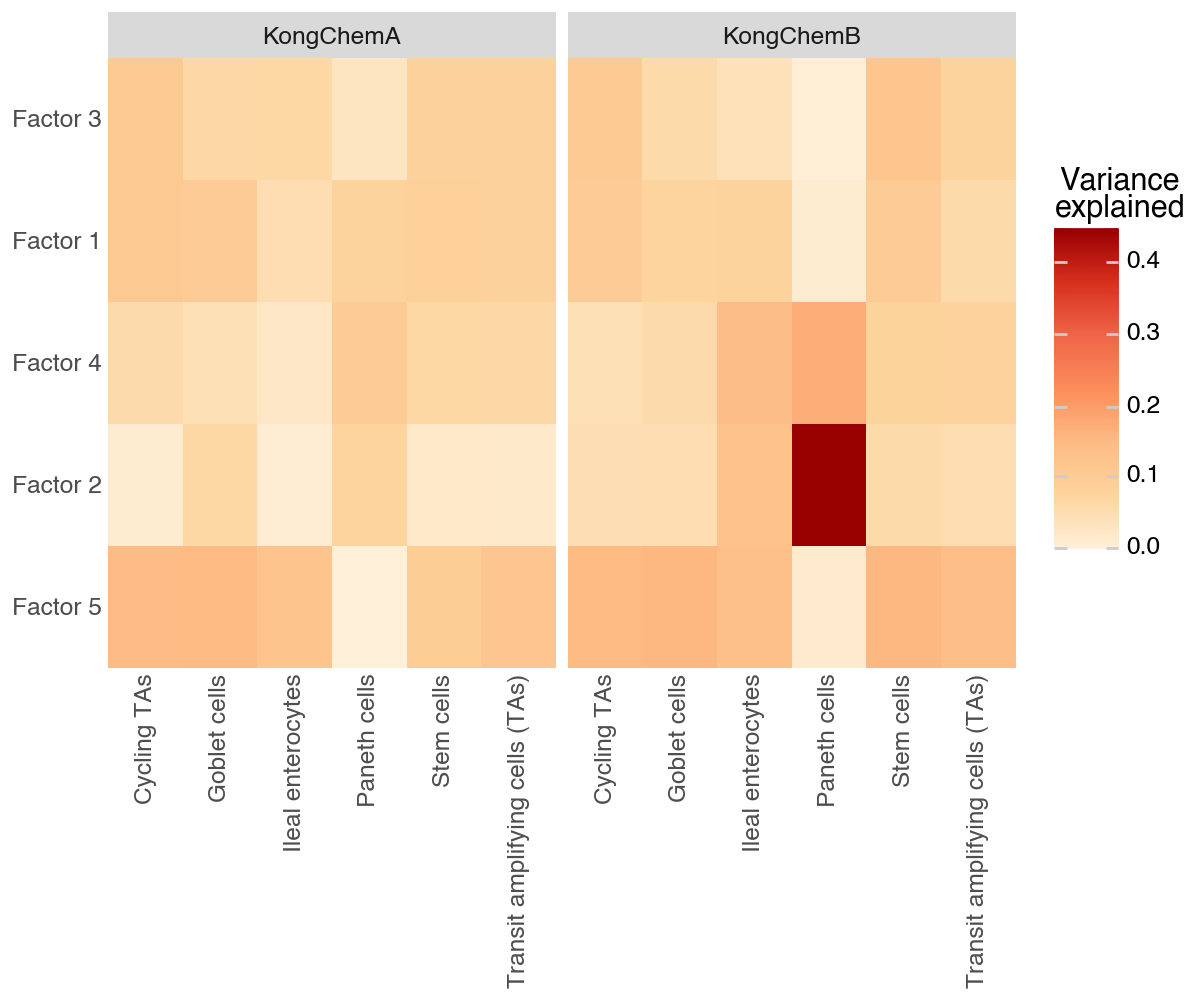

In [13]:
mf.pl.variance_explained(model_group)

## Doing statistics with the models

Given the availability of multiple groups one can do associations controling for random effects, following the same principles as in other tutorials

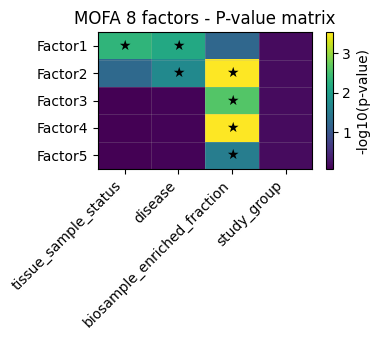

In [24]:
all_assocs = mina.down.get_pval_matrix(amodel,["tissue_sample_status", 
                                               "disease", 
                                               "biosample_enriched_fraction", 
                                               "study_group"])

mina.pl.pl.plot_pval_tiles(all_assocs, title="MOFA 8 factors - P-value matrix")
plt.show()

In [25]:
mina.down.get_associations(amodel, 
                           test_variable = "disease",
                           test_type="categorical", 
                           random_effect = "study_group")

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is sin

,feature,statistic,p_value,adj_p_value
0,Factor1,3.159344,0.001581,0.007906
1,Factor2,-2.785031,0.005352,0.013381
2,Factor3,0.284942,0.775688,0.775688
3,Factor4,0.481064,0.630471,0.775688
4,Factor5,0.579950,0.561949,0.775688


/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
... storing 'donor_id' as categorical


/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
... storing 'organ' as categorical
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
... storing 'library_preparation_protocol' as categorical
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
... storing 'biosample_enriched_fraction' as categorical
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
..

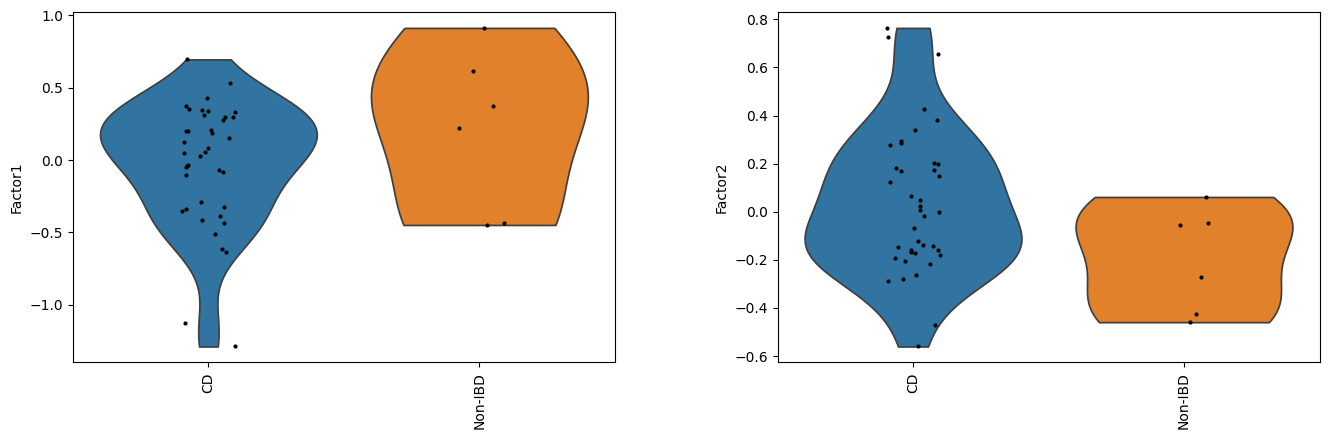

In [26]:
sc.pl.violin(amodel[amodel.obs["study_group"] == "KongChemA"],
             ["Factor1", "Factor2"], 
             groupby="disease", rotation=90,size = 3)

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
... storing 'donor_id' as categorical


/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
... storing 'organ' as categorical
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
... storing 'library_preparation_protocol' as categorical
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
... storing 'biosample_enriched_fraction' as categorical
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
..

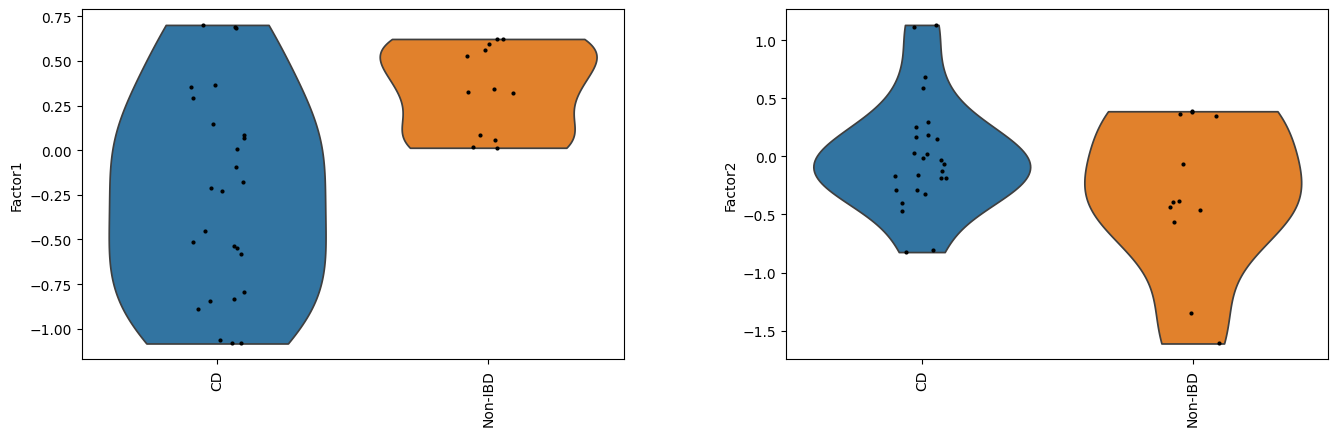

In [27]:
sc.pl.violin(amodel[amodel.obs["study_group"] == "KongChemB"],
             ["Factor1", "Factor2"], 
             groupby="disease", rotation=90,size = 3)

Here the interpretation has to consider the explained variance per cell type and group.

In this example, both Factor 1 and 2, associate with disease status regardless of the library preparation protocol. However, when examining the explained variance per group. Factor 2 has a clear bias towards Paneth cells in one of the chemistries. Our model is able to pick shared variance in other cells and protocols within this Factor, but one can assume that this disease signal is stronger in one cell type and chemistry. In contrast, Factor 1 has a more even distribution of explained variance across cell-types and protocols, and thus would be the signal to prioritize for downstream analyses.

As in the other tutorials, one can inspect functionally the factors of interest.

Running ULM for view: Stem cells
Running ULM for view: Paneth cells
Running ULM for view: Cycling TAs
Running ULM for view: Transit amplifying cells (TAs)
Running ULM for view: Ileal enterocytes
Running ULM for view: Goblet cells


/Users/flores/Dropbox/EBI/Research/MINA/src/mina/pl/pl.py:473: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


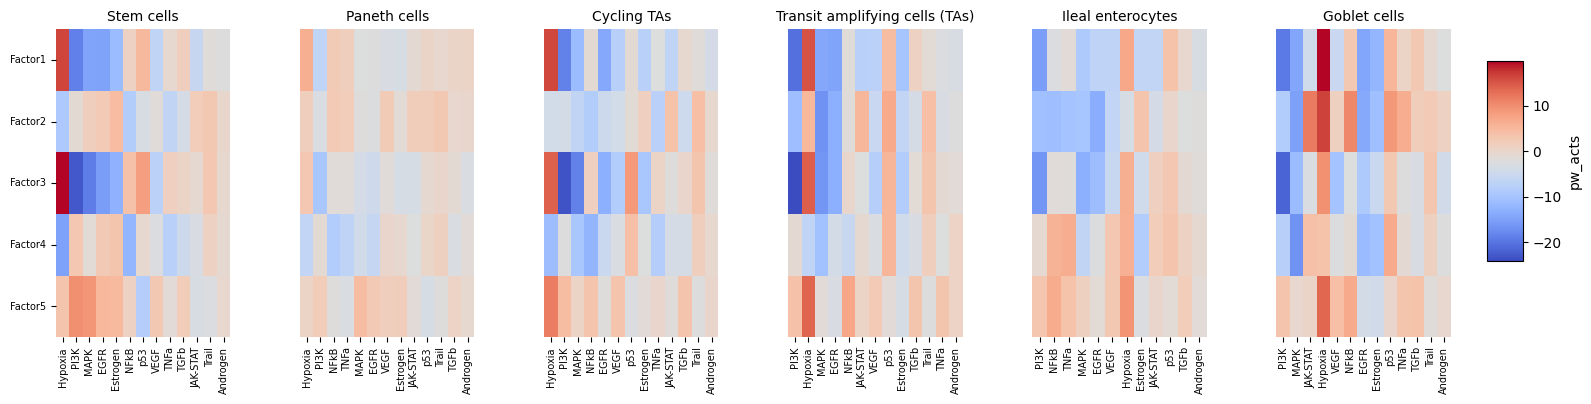

In [33]:
# Characterizing Factor Loadings
# First we need to make the gene loadings a pandas DataFrame with named columns and indexes

# Wrap as DataFrame for readability - This could be a function - users will forget to do this
gene_loadings = pd.DataFrame(amodel.varm["gene_loadings"], columns=amodel.uns['gene_loadings_columns'])
gene_loadings.index = amodel.var.index.to_list()

# Make a dictionary of gene expression data
gene_loadings = mina.down.split_by_view(gene_loadings)

# Now you can run decoupler for each matrix of gene loadings
progeny = dc.op.progeny(organism="human")
mcp_pws = mina.down.run_ulm_per_view(view_dict=gene_loadings, net=progeny)

mina.pl.plot_mcell_funcomics(mcp_pws, 
                     p_threshold=0.05,
                     top_n=15,
                     use_var=True,
                     figsize=(18, 4))

Among the usual inflammatory response in TAs and enterocytes, we observe that cells of control patients tend to have a higher activity of hypoxia, which could point to differences in sample handling. 

---

## Summary

In this vignette, we applied group-based multicellular factor analysis to model coordinated sample-level variation across epithelial cell types in inflammatory bowel disease across different technical experimental groups.

The key difference from the introductory tutorial is the explicit modeling of shared variance across cell-types and experimental groups, which allows to identify shared and unique signals of distinct groups.

This type of modeling is the basis for using factor analysis for meta-analysis

The next vignettes focus on a different type of modeling, where we want to guide factors based on feature-level prior knowledge.